# Урок 15.7. Вторая производная, выпуклость, Тейлор и Ньютон

**Интерактивная версия:** `lessons/lesson_15_7/web/index.html` — там те же опыты на живых графиках.

**После урока вы сможете:** вычислять вторую и высшие производные и оценивать $f''$ второй разностью;
находить точки перегиба и классифицировать экстремумы (тестом второй производной и высшими производными);
проверять выпуклость тремя признаками и применять неравенство Йенсена; определять, какие потери бустинга
выпуклы; строить многочлены Тейлора и оценивать их ошибку; выполнять шаги метода Ньютона, объяснять
квадратичную сходимость и чинить метод; выводить значение листа $-G/(H + \lambda)$ и прирост разбиения XGBoost.

Блоки урока:

1. **Вторая производная:** высшие производные, ускорение, вторая разность и выбор шага, изгиб, перегиб.
2. **Экстремумы и форма графика:** тест второй производной, высшие производные, исследование функции.
3. **Выпуклость:** три признака, «одна яма», неравенство Йенсена и ансамбли, выпуклость потерь.
4. **Ряд Тейлора:** многочлены, остаточный член и порядок ошибки, вычисления рядами, радиус сходимости.
5. **Метод Ньютона:** шаг, метод касательных, квадратичная сходимость, поломки и ремонт.
6. **Второй порядок в бустинге:** парабола потерь, значение листа, прирост разбиения, сверка с XGBoost.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import math

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib import animation
from scipy import optimize

from gbcourse.boosting import GradientBoosting
from gbcourse.losses import get_loss
from gbcourse.plotting import use_course_style
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, RED, SERIES, VIOLET

use_course_style()
plt.rcParams["animation.embed_limit"] = 30  # МБ: анимации встраиваются в ноутбук
sig = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731


def d2num(f, x, h=1e-4):
    """Вторая разность: (f(x + h) − 2f(x) + f(x − h)) / h²."""
    return (f(x + h) - 2 * f(x) + f(x - h)) / h**2

## Блок 1. Вторая производная

### 1. Производная от производной

Проверим формулы вторых производных из урока второй разностью, в том числе $\sigma'' = \sigma(1 - \sigma)(1 - 2\sigma)$.

In [2]:
checks = {
    "x⁴ − 3x² + 2x → 12x² − 6": (lambda x: x**4 - 3 * x**2 + 2 * x, lambda x: 12 * x**2 - 6),
    "e^(2x) → 4e^(2x)": (lambda x: np.exp(2 * x), lambda x: 4 * np.exp(2 * x)),
    "sin x → −sin x": (np.sin, lambda x: -np.sin(x)),
    "ln x → −1/x²": (np.log, lambda x: -1 / x**2),
    "x·eˣ → (x + 2)eˣ": (lambda x: x * np.exp(x), lambda x: (x + 2) * np.exp(x)),
    "σ → σ(1 − σ)(1 − 2σ)": (sig, lambda x: sig(x) * (1 - sig(x)) * (1 - 2 * sig(x))),
}
pts = np.array([0.3, 0.7, 1.1, 1.9])
for name, (f, f2) in checks.items():
    err = np.max(np.abs(d2num(f, pts) - f2(pts)))
    print(f"{name:28} max|Δ²f/h² − формула| = {err:.1e}")
    assert err < 1e-5

print("цикл синуса: производные порядка 0..8 в точке 1:", [round(math.sin(1 + k * math.pi / 2), 4) for k in range(9)])

x⁴ − 3x² + 2x → 12x² − 6     max|Δ²f/h² − формула| = 4.2e-07
e^(2x) → 4e^(2x)             max|Δ²f/h² − формула| = 5.1e-07
sin x → −sin x               max|Δ²f/h² − формула| = 1.6e-08
ln x → −1/x²                 max|Δ²f/h² − формула| = 6.1e-07
x·eˣ → (x + 2)eˣ             max|Δ²f/h² − формула| = 2.4e-07
σ → σ(1 − σ)(1 − 2σ)         max|Δ²f/h² − формула| = 2.1e-08
цикл синуса: производные порядка 0..8 в точке 1: [0.8415, 0.5403, -0.8415, -0.5403, 0.8415, 0.5403, -0.8415, -0.5403, 0.8415]


### 2. Ускорение: путь, скорость, ускорение для трёх сценариев

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


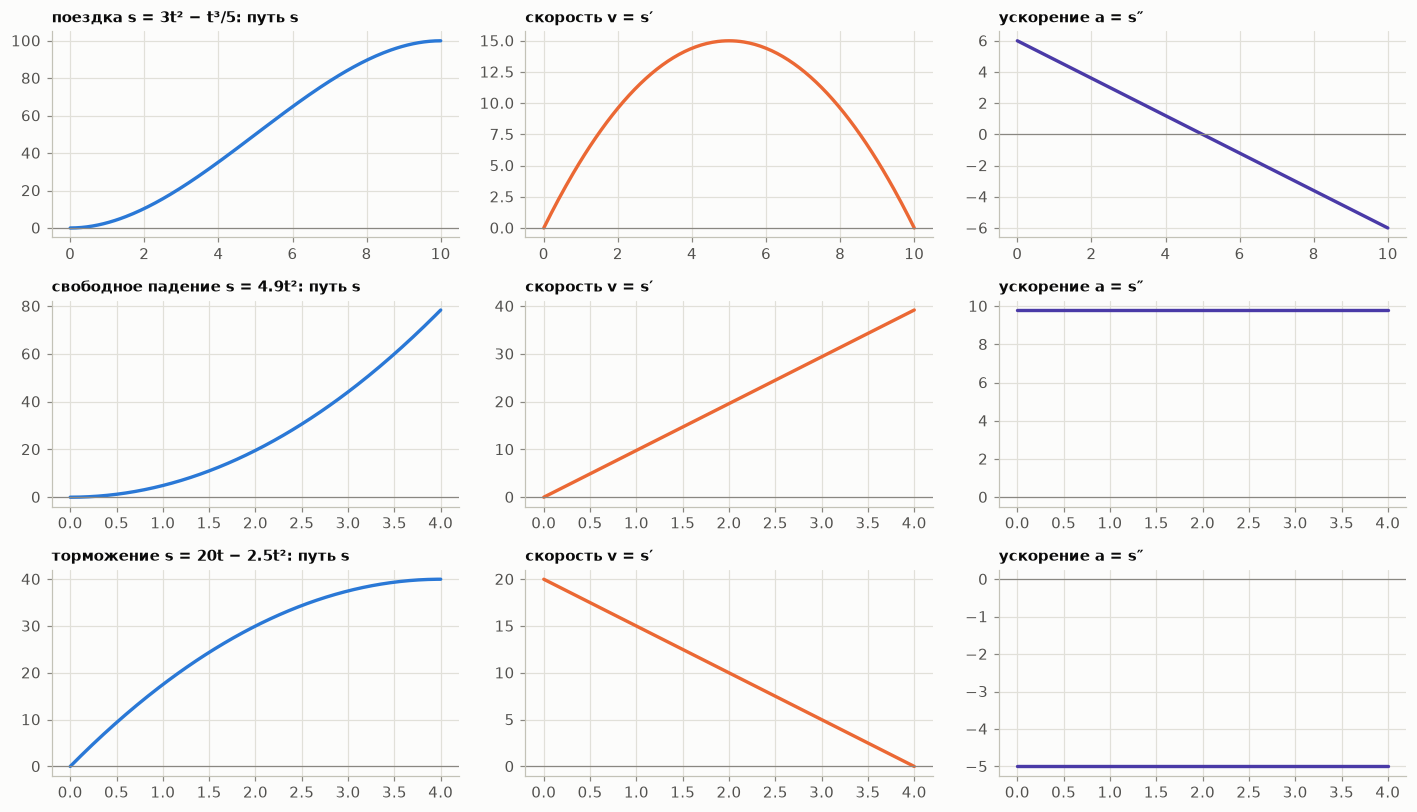

поездка: максимум скорости при t = 5: 15.0 м/с; торможение: путь до остановки 40.0 м


In [3]:
scen = {
    "поездка s = 3t² − t³/5": (10, lambda t: 3 * t**2 - t**3 / 5, lambda t: 6 * t - 0.6 * t**2, lambda t: 6 - 1.2 * t),
    "свободное падение s = 4.9t²": (4, lambda t: 4.9 * t**2, lambda t: 9.8 * t, lambda t: 9.8 + 0 * t),
    "торможение s = 20t − 2.5t²": (4, lambda t: 20 * t - 2.5 * t**2, lambda t: 20 - 5 * t, lambda t: -5 + 0 * t),
}
fig, axes = plt.subplots(3, 3, figsize=(13, 7.5))
for row, (name, (T, s, v, a)) in zip(axes, scen.items()):
    t = np.linspace(0, T, 201)
    for ax, y, lab, col in zip(row, [s(t), v(t), a(t)], ["путь s", "скорость v = s′", "ускорение a = s″"], [BLUE, ORANGE, VIOLET]):
        ax.plot(t, y, color=col, lw=2.2)
        ax.axhline(0, color=MUTED, lw=0.8)
        ax.set_title(f"{name}: {lab}" if lab == "путь s" else lab, fontsize=10)
plt.tight_layout()
plt.show()
print("поездка: максимум скорости при t = 5:", 6 * 5 - 0.6 * 25, "м/с; торможение: путь до остановки", 20 * 4 - 2.5 * 16, "м")

### 3. Вторая разность и выбор шага $h$

Ошибка метода $\approx h^2 |f^{(4)}|/12$, ошибка округления $\approx \varepsilon/h^2$. Лучший шаг — около $10^{-4}$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


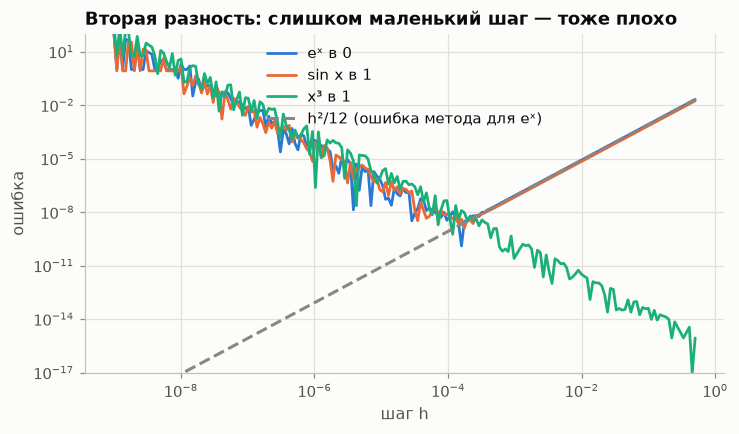

h =   1e-01: eˣ в нуле → 1.0008336112
h =   1e-02: eˣ в нуле → 1.0000083334
h =   1e-04: eˣ в нуле → 1.0000000050
h =   1e-06: eˣ в нуле → 0.9999778783
h =   1e-08: eˣ в нуле → -1.1102230246


In [4]:
hs = np.logspace(-9, -0.3, 200)
fig, ax = plt.subplots(figsize=(7.5, 4))
for name, f, x0, exact, col in [("eˣ в 0", np.exp, 0.0, 1.0, BLUE), ("sin x в 1", np.sin, 1.0, -math.sin(1), ORANGE),
                                ("x³ в 1", lambda x: x**3, 1.0, 6.0, AQUA)]:
    err = np.maximum(np.abs(np.array([d2num(f, x0, h) for h in hs]) - exact), 1e-17)
    ax.loglog(hs, err, color=col, lw=1.8, label=name)
ax.loglog(hs, hs**2 / 12, "--", color=MUTED, label="h²/12 (ошибка метода для eˣ)")
ax.set(xlabel="шаг h", ylabel="ошибка", title="Вторая разность: слишком маленький шаг — тоже плохо", ylim=(1e-17, 1e2))
ax.legend()
plt.show()
for h in [1e-1, 1e-2, 1e-4, 1e-6, 1e-8]:
    print(f"h = {h:7.0e}: eˣ в нуле → {d2num(np.exp, 0.0, h):.10f}")

### 4–5. Изгиб и точки перегиба

$f'' > 0$ — график над касательной: $e^x \ge 1 + x$, а $\ln x \le x - 1$ (купол). Перегиб — смена знака $f''$,
там же экстремум наклона $f'$.

min(eˣ − (1 + x)) = 4.495503373003196e-06 ≥ 0
max(ln x − (x − 1)) = -1.997337326864468e-06 ≤ 0
(1 − 1/n)ⁿ ≤ 1/e: [0.3487, 0.366, 0.3677] ≤ 0.3679
x³ − 3x²               перегибы: [1.]
σ(F)                   перегибы: [0.]
колокол e^(−x²/2)      перегибы: [-1.  1.]
x⁴ (ложный кандидат)   перегибы: []


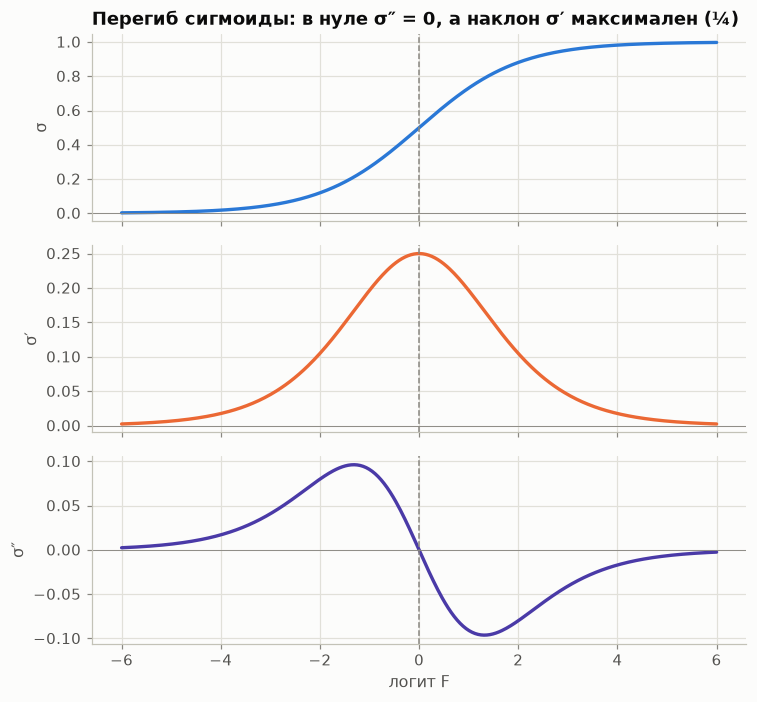

In [5]:
x = np.linspace(-4, 3, 1001)
print("min(eˣ − (1 + x)) =", np.min(np.exp(x) - 1 - x), "≥ 0")
xp = np.linspace(0.05, 6, 1001)
print("max(ln x − (x − 1)) =", np.max(np.log(xp) - xp + 1), "≤ 0")
print("(1 − 1/n)ⁿ ≤ 1/e:", [round((1 - 1 / n) ** n, 4) for n in (10, 100, 1000)], "≤", round(1 / math.e, 4))


def inflections(f2, a, b, n=200000):
    """Точки, где f″ меняет знак (по сетке с чётным числом узлов: кандидат не попадает точно в узел)."""
    xs = np.linspace(a, b, n)
    s = np.sign(f2(xs))
    i = np.where(s[:-1] * s[1:] < 0)[0]
    return (xs[i] + xs[i + 1]) / 2


cases = {
    "x³ − 3x²": (lambda z: 6 * z - 6, -1, 3),
    "σ(F)": (lambda z: sig(z) * (1 - sig(z)) * (1 - 2 * sig(z)), -6, 6),
    "колокол e^(−x²/2)": (lambda z: (z**2 - 1) * np.exp(-(z**2) / 2), -3.5, 3.5),
    "x⁴ (ложный кандидат)": (lambda z: 12 * z**2, -1.5, 1.5),
}
for name, (f2, a, b) in cases.items():
    print(f"{name:22} перегибы: {np.round(inflections(f2, a, b), 4)}")

fig, axes = plt.subplots(3, 1, figsize=(7, 6.5), sharex=True)
F = np.linspace(-6, 6, 400)
for ax, y, lab, col in zip(axes, [sig(F), sig(F) * (1 - sig(F)), sig(F) * (1 - sig(F)) * (1 - 2 * sig(F))], ["σ", "σ′", "σ″"], [BLUE, ORANGE, VIOLET]):
    ax.plot(F, y, color=col, lw=2.2)
    ax.axvline(0, color=MUTED, ls="--", lw=1)
    ax.axhline(0, color=MUTED, lw=0.6)
    ax.set_ylabel(lab)
axes[0].set_title("Перегиб сигмоиды: в нуле σ″ = 0, а наклон σ′ максимален (¼)")
axes[-1].set_xlabel("логит F")
plt.tight_layout()
plt.show()

## Блок 2. Экстремумы и форма графика

### 6. Тест второй производной

Критические точки многочленов — корни $f'$ (`np.roots`), классификация — знак $f''$.

In [6]:
def classify(coefs):
    d1, d2_ = np.polyder(coefs), np.polyder(coefs, 2)
    for r in np.unique(np.round(np.roots(d1).real, 9)):  # кратные корни — один раз
        k = np.polyval(d2_, r)
        kind = "минимум" if k > 1e-9 else "максимум" if k < -1e-9 else "тест молчит"
        print(f"   x = {r:+.4f}: f = {np.polyval(coefs, r):+.4f}, f″ = {k:+.4f} → {kind}")


for name, c in [("x³/3 − x", [1 / 3, 0, -1, 0]), ("x³ − 6x² + 9x", [1, -6, 9, 0]), ("2x³ − 3x² − 12x", [2, -3, -12, 0]), ("x⁴ − 4x³", [1, -4, 0, 0, 0])]:
    print(name)
    classify(c)

# Лучшая константа для MSE и log-loss — минимум (вторая производная положительна)
y = np.array([2, 4, 3, 7, 9, 11.0])
res = optimize.minimize_scalar(lambda c: ((y - c) ** 2).sum())
print("MSE: argmin =", round(res.x, 6), "= среднее", y.mean(), "; L″ = 2n =", 2 * len(y))
yb = np.array([1] * 8 + [0] * 2)
res = optimize.minimize_scalar(lambda F: get_loss("logistic").loss(yb, np.full(10, F)))
print("log-loss: argmin =", round(res.x, 6), "= ln(0.8/0.2) =", round(math.log(4), 6), "= init gbcourse", round(get_loss("logistic").init(yb), 6))

x³/3 − x
   x = -1.0000: f = +0.6667, f″ = -2.0000 → максимум
   x = +1.0000: f = -0.6667, f″ = +2.0000 → минимум
x³ − 6x² + 9x
   x = +1.0000: f = +4.0000, f″ = -6.0000 → максимум
   x = +3.0000: f = +0.0000, f″ = +6.0000 → минимум
2x³ − 3x² − 12x
   x = -1.0000: f = +7.0000, f″ = -18.0000 → максимум
   x = +2.0000: f = -20.0000, f″ = +18.0000 → минимум
x⁴ − 4x³
   x = +0.0000: f = +0.0000, f″ = +0.0000 → тест молчит
   x = +3.0000: f = -27.0000, f″ = +36.0000 → минимум
MSE: argmin = 6.0 = среднее 6.0 ; L″ = 2n = 12
log-loss: argmin = 1.386294 = ln(0.8/0.2) = 1.386294 = init gbcourse 1.386294


### 7. Когда тест молчит: первая ненулевая производная

Чётный порядок — экстремум, нечётный — терраса. Проверим знаками $f(a \pm \Delta) - f(a)$.

In [7]:
for name, f, a in [("x⁴ − 4x³ в 0", lambda z: z**4 - 4 * z**3, 0.0), ("x⁴ − 4x³ в 3", lambda z: z**4 - 4 * z**3, 3.0),
                   ("cos x − 1 + x²/2 в 0", lambda z: np.cos(z) - 1 + z**2 / 2, 0.0), ("sin x − x в 0", lambda z: np.sin(z) - z, 0.0),
                   ("x⁵ в 0", lambda z: z**5, 0.0), ("−x⁶ в 0", lambda z: -(z**6), 0.0)]:
    lft, rgt = f(a - 0.01) - f(a), f(a + 0.01) - f(a)
    verdict = "минимум" if lft > 0 and rgt > 0 else "максимум" if lft < 0 and rgt < 0 else "экстремума нет"
    print(f"{name:22} f(a − 0.01) − f(a) = {lft:+.2e}, f(a + 0.01) − f(a) = {rgt:+.2e} → {verdict}")
print("cos x ≥ 1 − x²/2 на [−10, 10]:", np.min(np.cos(x := np.linspace(-10, 10, 20001)) - 1 + x**2 / 2) >= -1e-15)

x⁴ − 4x³ в 0           f(a − 0.01) − f(a) = +4.01e-06, f(a + 0.01) − f(a) = -3.99e-06 → экстремума нет
x⁴ − 4x³ в 3           f(a − 0.01) − f(a) = +1.79e-03, f(a + 0.01) − f(a) = +1.81e-03 → минимум
cos x − 1 + x²/2 в 0   f(a − 0.01) − f(a) = +4.17e-10, f(a + 0.01) − f(a) = +4.17e-10 → минимум
sin x − x в 0          f(a − 0.01) − f(a) = +1.67e-07, f(a + 0.01) − f(a) = -1.67e-07 → экстремума нет
x⁵ в 0                 f(a − 0.01) − f(a) = -1.00e-10, f(a + 0.01) − f(a) = +1.00e-10 → экстремума нет
−x⁶ в 0                f(a − 0.01) − f(a) = -1.00e-12, f(a + 0.01) − f(a) = -1.00e-12 → максимум
cos x ≥ 1 − x²/2 на [−10, 10]: True


### 8. Полное исследование функции: таблица знаков

In [8]:
def study(f, f1, f2, a, b, name):
    xs = np.linspace(a, b, 200001)
    cuts = []
    for g in (f1, f2):
        v = g(xs)
        i = np.where(np.sign(v[:-1]) * np.sign(v[1:]) <= 0)[0]
        cuts += list(np.round((xs[i] + xs[i + 1]) / 2, 4))
    bounds = [a, *sorted(set(cuts)), b]
    print(name)
    for lo, hi in zip(bounds[:-1], bounds[1:]):
        if hi - lo < 1e-6:
            continue
        m = (lo + hi) / 2
        print(f"   ({lo:6.2f}; {hi:6.2f}):  f′ {'+' if f1(m) > 0 else '−'}  f″ {'+' if f2(m) > 0 else '−'}  →  {'↗' if f1(m) > 0 else '↘'}{'∪' if f2(m) > 0 else '∩'}")


study(lambda z: z**3 - 6 * z**2 + 9 * z, lambda z: 3 * z**2 - 12 * z + 9, lambda z: 6 * z - 12, -1, 5, "x³ − 6x² + 9x")
study(lambda z: np.exp(-(z**2) / 2), lambda z: -z * np.exp(-(z**2) / 2), lambda z: (z**2 - 1) * np.exp(-(z**2) / 2), -3.5, 3.5, "e^(−x²/2)")
study(lambda z: z**4 - 4 * z**3, lambda z: 4 * z**3 - 12 * z**2, lambda z: 12 * z**2 - 24 * z, -1.5, 4.5, "x⁴ − 4x³")

x³ − 6x² + 9x
   ( -1.00;   1.00):  f′ +  f″ −  →  ↗∩
   (  1.00;   2.00):  f′ −  f″ −  →  ↘∩
   (  2.00;   3.00):  f′ −  f″ +  →  ↘∪
   (  3.00;   5.00):  f′ +  f″ +  →  ↗∪
e^(−x²/2)
   ( -3.50;  -1.00):  f′ +  f″ +  →  ↗∪
   ( -1.00;   0.00):  f′ +  f″ −  →  ↗∩
   (  0.00;   1.00):  f′ −  f″ −  →  ↘∩
   (  1.00;   3.50):  f′ −  f″ +  →  ↘∪
x⁴ − 4x³
   ( -1.50;  -0.00):  f′ −  f″ +  →  ↘∪
   ( -0.00;   2.00):  f′ −  f″ −  →  ↘∩
   (  2.00;   3.00):  f′ −  f″ +  →  ↘∪
   (  3.00;   4.50):  f′ +  f″ +  →  ↗∪


## Блок 3. Выпуклость

### 10–11. Хорда, касательная и $f'' \ge 0$ — три признака дают один ответ

In [9]:
rng = np.random.default_rng(0)  # здесь сравнения с веб-версией нет — numpy-генератор допустим


def convex_checks(f, f1, f2, a, b, n=4000):
    x1, x2, t = rng.uniform(a, b, n), rng.uniform(a, b, n), rng.uniform(0, 1, n)
    chord = np.all(f(t * x1 + (1 - t) * x2) <= t * f(x1) + (1 - t) * f(x2) + 1e-10)
    tangent = np.all(f(x2) >= f(x1) + f1(x1) * (x2 - x1) - 1e-10)
    curv = np.all(f2(np.linspace(a, b, 2001)) >= -1e-12)
    return chord, tangent, curv


for name, f, f1, f2, a, b in [
    ("eˣ + x²", lambda z: np.exp(z) + z**2, lambda z: np.exp(z) + 2 * z, lambda z: np.exp(z) + 2, -2, 1.5),
    ("log-loss", lambda z: np.log1p(np.exp(-z)), lambda z: sig(z) - 1, lambda z: sig(z) * (1 - sig(z)), -5, 5),
    ("x⁴", lambda z: z**4, lambda z: 4 * z**3, lambda z: 12 * z**2, -1.4, 1.4),
    ("x⁴ − x²", lambda z: z**4 - z**2, lambda z: 4 * z**3 - 2 * z, lambda z: 12 * z**2 - 2, -1.1, 1.1),
    ("x³", lambda z: z**3, lambda z: 3 * z**2, lambda z: 6 * z, -1.5, 1.5),
]:
    c = convex_checks(f, f1, f2, a, b)
    print(f"{name:10} хорда {c[0]!s:5}  касательная {c[1]!s:5}  f″ ≥ 0 {c[2]!s:5}")
    assert len(set(c)) == 1

eˣ + x²    хорда True   касательная True   f″ ≥ 0 True 
log-loss   хорда True   касательная True   f″ ≥ 0 True 
x⁴         хорда True   касательная True   f″ ≥ 0 True 
x⁴ − x²    хорда False  касательная False  f″ ≥ 0 False
x³         хорда False  касательная False  f″ ≥ 0 False


### 12. Одна яма: спуск из девяти стартов

In [10]:
def descend(f1, starts, eta, steps=200, lo=-5, hi=5):
    x = np.array(starts, float)
    for _ in range(steps):
        x = np.clip(x - eta * f1(x), lo, hi)
    return x


starts = np.linspace(-1.55, 1.55, 9)
fins = {
    "x² + e^(−x) (выпуклая)": descend(lambda z: 2 * z - np.exp(-z), np.linspace(-2.05, 2.85, 9), 0.15),
    "x⁴ − 2x² + 0.3x (две ямы)": descend(lambda z: 4 * z**3 - 4 * z + 0.3, starts, 0.05),
    "x²/8 + sin 3x (много ям)": descend(lambda z: z / 4 + 3 * np.cos(3 * z), np.linspace(-3.85, 3.85, 9), 0.04),
}
for name, fin in fins.items():
    print(f"{name:28} финиши: {np.round(fin, 3)}  разных: {len(np.unique(np.round(fin, 2)))}")
print("корень 2x = e^(−x):", optimize.brentq(lambda z: 2 * z - np.exp(-z), 0, 1))

x² + e^(−x) (выпуклая)       финиши: [0.352 0.352 0.352 0.352 0.352 0.352 0.352 0.352 0.352]  разных: 1
x⁴ − 2x² + 0.3x (две ямы)    финиши: [-1.036 -1.036 -1.036 -1.036 -1.036  0.96   0.96   0.96   0.96 ]  разных: 2
x²/8 + sin 3x (много ям)     финиши: [-4.582 -2.547 -2.547 -0.509 -0.509  1.528  1.528  3.565  3.565]  разных: 5
корень 2x = e^(−x): 0.3517337112495754


### 14. Неравенство Йенсена: ансамбль-среднее не хуже средней модели

Для выпуклых потерь $L(y, \bar F) \le \overline{L(y, F_k)}$ на каждом объекте. Проверим на трёх моделях и на
бэггинге деревьев.

In [11]:
yv, preds = 4.0, np.array([2.0, 4.0, 9.0])
print("ошибки моделей:", (preds - yv) ** 2, "среднее", ((preds - yv) ** 2).mean(), "| ошибка среднего прогноза:", (preds.mean() - yv) ** 2)

from sklearn.tree import DecisionTreeRegressor  # noqa: E402

Xr = rng.uniform(0, 6, (300, 1))
yr = np.sin(Xr[:, 0]) + rng.normal(0, 0.3, 300)
Xt = np.linspace(0, 6, 400).reshape(-1, 1)
yt = np.sin(Xt[:, 0])
P = []
for k in range(25):
    idx = rng.integers(0, 300, 300)  # бутстрэп
    P.append(DecisionTreeRegressor(max_depth=6, random_state=k).fit(Xr[idx], yr[idx]).predict(Xt))
P = np.array(P)
avg_loss = ((P - yt) ** 2).mean()
loss_avg = ((P.mean(axis=0) - yt) ** 2).mean()
print(f"средняя MSE одного дерева: {avg_loss:.4f}  ≥  MSE усреднения 25 деревьев: {loss_avg:.4f}")
assert loss_avg <= avg_loss
# поточечно: разность = дисперсия прогнозов
print("разность = средняя дисперсия прогнозов:", round(avg_loss - loss_avg, 6), "=", round(P.var(axis=0).mean(), 6))

ошибки моделей: [ 4.  0. 25.] среднее 9.666666666666666 | ошибка среднего прогноза: 1.0


средняя MSE одного дерева: 0.0462  ≥  MSE усреднения 25 деревьев: 0.0183
разность = средняя дисперсия прогнозов: 0.027957 = 0.027957


### 15. Выпуклость потерь бустинга по прогнозу $F$

In [12]:
F = np.linspace(-6, 6, 120001)
losses_h = {
    "½(y − F)²": np.ones_like(F),
    "log-loss": sig(F) * (1 - sig(F)),
    "Пуассон (y = 3)": np.exp(np.clip(F, -6, 2.5)),
    "экспоненциальные": np.exp(-np.clip(F, -2, 6)),
    "(1 − σ(F))² — MSE по вероятности": -2 * sig(F) * (1 - sig(F)) ** 2 * (1 - 3 * sig(F)),
    "Коши ln(1 + F²)": 2 * (1 - F**2) / (1 + F**2) ** 2,
}
def intervals(mask):
    """Отрезки сетки F, где mask истинна."""
    edges = np.flatnonzero(np.diff(np.r_[0, mask.astype(int), 0]))
    return [(F[a], F[b - 1]) for a, b in zip(edges[::2], edges[1::2])]


for name, h in losses_h.items():
    bad = intervals(h < 0)
    rng_txt = "не выпукла на " + ", ".join(f"[{a:.3f}; {b:.3f}]" for a, b in bad) if bad else "выпукла"
    print(f"{name:36} min h = {h.min():+.4f}  {rng_txt}")
print("граница для MSE по вероятности: F = −ln 2 =", round(-math.log(2), 4))

½(y − F)²                            min h = +1.0000  выпукла
log-loss                             min h = +0.0025  выпукла
Пуассон (y = 3)                      min h = +0.0025  выпукла
экспоненциальные                     min h = +0.0025  выпукла
(1 − σ(F))² — MSE по вероятности     min h = -0.1202  не выпукла на [-6.000; -0.693]
Коши ln(1 + F²)                      min h = -0.2500  не выпукла на [-6.000; -1.000], [1.000; 6.000]
граница для MSE по вероятности: F = −ln 2 = -0.6931


## Блок 4. Ряд Тейлора

### 16–17. Парабола и многочлены Тейлора

In [13]:
print("√4.1: точно", math.sqrt(4.1), " касательная", 2.025, f"(ошибка {abs(math.sqrt(4.1) - 2.025):.1e})",
      " парабола", 2.025 - 0.01 / 64, f"(ошибка {abs(math.sqrt(4.1) - 2.025 + 0.01 / 64):.1e})")

xs = np.linspace(-7, 7, 600)
fig, ax = plt.subplots(figsize=(7, 3.8), dpi=72)


def taylor_sin(xv, deg):
    out = np.zeros_like(xv)
    for k in range(1, deg + 1, 2):
        out += (-1) ** ((k - 1) // 2) * xv**k / math.factorial(k)
    return out


def frame(i):
    deg = 2 * i + 1
    ax.clear()
    ax.plot(xs, np.sin(xs), color=BLUE, lw=2.6, label="sin x")
    ax.plot(xs, taylor_sin(xs, deg), "--", color=VIOLET, lw=2, label=f"многочлен степени {deg}")
    ax.set(ylim=(-2.5, 2.5), title=f"sin x и его ряд Тейлора, степень {deg}")
    ax.legend(loc="upper right")
    return []


anim = animation.FuncAnimation(fig, frame, frames=9, interval=900)
plt.close(fig)
display(HTML(anim.to_jshtml()))

√4.1: точно 2.0248456731316584  касательная 2.025 (ошибка 1.5e-04)  парабола 2.02484375 (ошибка 1.9e-06)


### 18. Остаточный член: ошибка порядка $\Delta^{n+1}$

На двойной логарифмической шкале — прямые с наклоном $n + 1$. У синуса чётных членов нет, поэтому
наклоны 3, 3, 5, 5; у log-loss нет члена $F^3$ — парабола XGBoost ошибается как $\Delta^4$.

eˣ        наклоны при n = 0..4: [1.04 2.02 3.02 4.01 5.01]
sin x     наклоны при n = 0..4: [1. 3. 3. 5. 5.]
log-loss  наклоны при n = 0..4: [0.98 2.   4.   4.   6.  ]


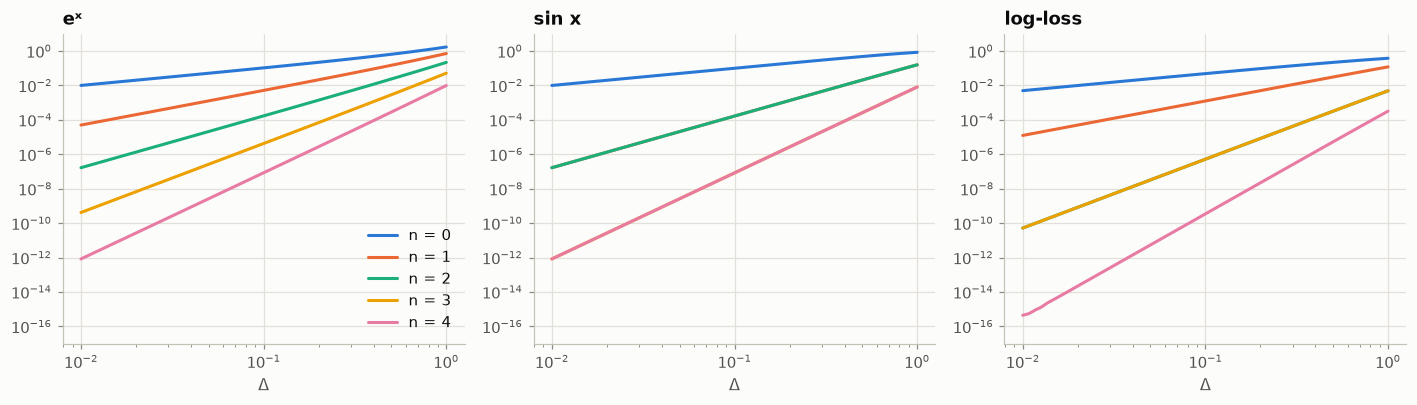

e,  1 членов: 1.0000000000  ошибка 1.7e+00  оценка 3/(n+1)! = 3.0e+00
e,  2 членов: 2.0000000000  ошибка 7.2e-01  оценка 3/(n+1)! = 1.5e+00
e,  3 членов: 2.5000000000  ошибка 2.2e-01  оценка 3/(n+1)! = 5.0e-01
e,  4 членов: 2.6666666667  ошибка 5.2e-02  оценка 3/(n+1)! = 1.2e-01
e,  5 членов: 2.7083333333  ошибка 9.9e-03  оценка 3/(n+1)! = 2.5e-02
e,  6 членов: 2.7166666667  ошибка 1.6e-03  оценка 3/(n+1)! = 4.2e-03
e,  7 членов: 2.7180555556  ошибка 2.3e-04  оценка 3/(n+1)! = 6.0e-04
e,  8 членов: 2.7182539683  ошибка 2.8e-05  оценка 3/(n+1)! = 7.4e-05
e,  9 членов: 2.7182787698  ошибка 3.1e-06  оценка 3/(n+1)! = 8.3e-06
e, 10 членов: 2.7182815256  ошибка 3.0e-07  оценка 3/(n+1)! = 8.3e-07
e, 11 членов: 2.7182818011  ошибка 2.7e-08  оценка 3/(n+1)! = 7.5e-08


In [14]:
coefs = {
    "eˣ": (np.exp, [1 / math.factorial(k) for k in range(6)]),
    "sin x": (np.sin, [0, 1, 0, -1 / 6, 0, 1 / 120]),
    "log-loss": (lambda z: np.log1p(np.exp(-z)), [math.log(2), -0.5, 1 / 8, 0, -1 / 192, 0]),
}
ds = np.logspace(-2, 0, 60)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (name, (f, c)) in zip(axes, coefs.items()):
    slopes = []
    for n in range(5):
        Pn = lambda d, n=n, c=c: sum(c[k] * d**k for k in range(n + 1))  # noqa: E731
        err = np.abs(f(ds) - Pn(ds))
        ax.loglog(ds, np.maximum(err, 1e-17), color=SERIES[n], label=f"n = {n}")
        slopes.append(math.log2(abs(f(0.1) - Pn(0.1)) / abs(f(0.05) - Pn(0.05))))
    ax.set(title=name, xlabel="Δ", ylim=(1e-17, 10))
    print(f"{name:9} наклоны при n = 0..4: {np.round(slopes, 2)}")
axes[0].legend()
plt.tight_layout()
plt.show()

s_ = 0.0
for n in range(11):
    s_ += 1 / math.factorial(n)
    print(f"e, {n + 1:2} членов: {s_:.10f}  ошибка {math.e - s_:.1e}  оценка 3/(n+1)! = {3 / math.factorial(n + 1):.1e}")

### 19. Вычисления рядами: медленный и быстрый ряд для $\ln 2$; пределы

In [15]:
for N in (10, 100, 1000):
    print(f"ln 2 = 1 − 1/2 + 1/3 − …, {N:4} членов: ошибка {abs(sum((-1) ** k / (k + 1) for k in range(N)) - math.log(2)):.1e}")
for N in (2, 4, 6):
    v = sum(2 * (1 / 3) ** (2 * k + 1) / (2 * k + 1) for k in range(N))
    print(f"ln 2 = 2(x + x³/3 + …) при x = 1/3, {N} членов: ошибка {abs(v - math.log(2)):.1e}")
for x0 in (0.1, 0.01):
    print(f"x = {x0}: (sin x − x)/x³ = {(math.sin(x0) - x0) / x0**3:.7f} → −1/6;  (eˣ − 1 − x)/x² = {(math.exp(x0) - 1 - x0) / x0**2:.6f} → 1/2")
print("численная производная eˣ в 0, h = 0.01: правая разность — ошибка",
      f"{(math.exp(0.01) - 1) / 0.01 - 1:.6f} ≈ h/2;  центральная — {(math.exp(0.01) - math.exp(-0.01)) / 0.02 - 1:.2e} ≈ h²/6")

ln 2 = 1 − 1/2 + 1/3 − …,   10 членов: ошибка 4.8e-02
ln 2 = 1 − 1/2 + 1/3 − …,  100 членов: ошибка 5.0e-03
ln 2 = 1 − 1/2 + 1/3 − …, 1000 членов: ошибка 5.0e-04
ln 2 = 2(x + x³/3 + …) при x = 1/3, 2 членов: ошибка 1.8e-03
ln 2 = 2(x + x³/3 + …) при x = 1/3, 4 членов: ошибка 1.2e-05
ln 2 = 2(x + x³/3 + …) при x = 1/3, 6 членов: ошибка 1.1e-07
x = 0.1: (sin x − x)/x³ = -0.1665834 → −1/6;  (eˣ − 1 − x)/x² = 0.517092 → 1/2
x = 0.01: (sin x − x)/x³ = -0.1666658 → −1/6;  (eˣ − 1 − x)/x² = 0.501671 → 1/2
численная производная eˣ в 0, h = 0.01: правая разность — ошибка 0.005017 ≈ h/2;  центральная — 1.67e-05 ≈ h²/6


### 20. Где ряд перестаёт работать: $\frac{1}{1 + x^2}$ и $e^{-1/x^2}$

In [16]:
for xv in (0.5, 0.9, 1.2):
    row = [sum((-1) ** m * xv ** (2 * m) for m in range(n // 2 + 1)) for n in (2, 6, 10, 20)]
    print(f"x = {xv}: 1/(1 + x²) = {1 / (1 + xv * xv):.6f};  многочлены степени 2, 6, 10, 20: {np.round(row, 6)}")
print("e^(−1/x²) в точке 0.5:", math.exp(-4), "— а все многочлены Тейлора в нуле тождественно равны 0")

x = 0.5: 1/(1 + x²) = 0.800000;  многочлены степени 2, 6, 10, 20: [0.75     0.796875 0.799805 0.8     ]
x = 0.9: 1/(1 + x²) = 0.552486;  многочлены степени 2, 6, 10, 20: [0.19     0.314659 0.396448 0.606893]
x = 1.2: 1/(1 + x²) = 0.409836;  многочлены степени 2, 6, 10, 20: [-0.44     -1.352384 -3.244303 23.035305]
e^(−1/x²) в точке 0.5: 0.01831563888873418 — а все многочлены Тейлора в нуле тождественно равны 0


## Блок 5. Метод Ньютона

### 21–23. Шаг Ньютона и квадратичная сходимость

$e_{k+1} \approx C e_k^2$, $C = f'''/(2f'')$. Для $e^x - 2x$: $C = \frac12$.

In [17]:
xn = xg = 2.0
x_opt = math.log(2)
prev = None
print(" k   Ньютон |eₖ|   eₖ/eₖ₋₁²   спуск η = 0.3")
for k in range(8):
    e = abs(xn - x_opt)
    ratio = f"{e / prev**2:.4f}" if prev and e > 1e-15 else "   —  "
    print(f"{k:2}   {e:10.2e}   {ratio:>8}   {abs(xg - x_opt):.2e}")
    prev = e if e > 1e-15 else None
    xn -= (math.exp(xn) - 2) / math.exp(xn)
    xg -= 0.3 * (math.exp(xg) - 2)
print("scipy.optimize.newton для f′ = eˣ − 2:", optimize.newton(lambda z: math.exp(z) - 2, 2.0, fprime=math.exp))

 k   Ньютон |eₖ|   eₖ/eₖ₋₁²   спуск η = 0.3
 0     1.31e+00        —     1.31e+00
 1     5.78e-01     0.3382   3.10e-01
 2     1.39e-01     0.4162   1.50e-01
 3     9.20e-03     0.4776   6.64e-02
 4     4.22e-05     0.4985   2.79e-02
 5     8.91e-10     0.5000   1.14e-02
 6     0.00e+00        —     4.59e-03
 7     0.00e+00        —     1.84e-03
scipy.optimize.newton для f′ = eˣ − 2: 0.6931471805599453


### 22. Метод касательных: √2, cos x = x, цикл и разбегание

In [18]:
def newton_root(g, dg, x, steps):
    out = [x]
    for _ in range(steps):
        x = x - g(x) / dg(x)
        out.append(x)
    return out


print("√2:", [f"{v:.12f}" for v in newton_root(lambda z: z * z - 2, lambda z: 2 * z, 1.0, 5)])
print("cos x = x:", [f"{v:.10f}" for v in newton_root(lambda z: math.cos(z) - z, lambda z: -math.sin(z) - 1, 1.0, 4)])
print("x³ − 2x + 2 из 0:", newton_root(lambda z: z**3 - 2 * z + 2, lambda z: 3 * z * z - 2, 0.0, 5))
for x0 in (1.3, 1.5):
    print(f"arctg из {x0}:", np.round(newton_root(math.atan, lambda z: 1 / (1 + z * z), x0, 5), 3))
print("порог сходимости для arctg:", optimize.brentq(lambda z: 2 * z - math.atan(z) * (1 + z * z), 1, 2))

√2: ['1.000000000000', '1.500000000000', '1.416666666667', '1.414215686275', '1.414213562375', '1.414213562373']
cos x = x: ['1.0000000000', '0.7503638678', '0.7391128909', '0.7390851334', '0.7390851332']
x³ − 2x + 2 из 0: [0.0, 1.0, 0.0, 1.0, 0.0, 1.0]
arctg из 1.3: [ 1.3   -1.162  0.859 -0.374  0.034 -0.   ]
arctg из 1.5: [ 1.500000e+00 -1.694000e+00  2.321000e+00 -5.114000e+00  3.229600e+01
 -1.575317e+03]
порог сходимости для arctg: 1.3917452002707347


### 24. Поломки и ремонт: демпфирование $\eta$, сдвиг $\lambda$, обрезка шага, $|f''|$

In [19]:
def newton_fixed(d1, d2, x, eta=1.0, lam=0.0, clip=0.0, use_abs=False, steps=10):
    out = [x]
    for _ in range(steps):
        h = (abs(d2(x)) if use_abs else d2(x)) + lam
        st = -d1(x) / h
        if clip:
            st = max(-clip, min(clip, st))
        x = x + eta * st
        out.append(x)
        if abs(x) > 1e8:
            break
    return out


hyp = (lambda z: z / math.sqrt(1 + z * z), lambda z: (1 + z * z) ** -1.5)
for label, kw in [("без ремонта", {}), ("обрезка 1", {"clip": 1}), ("λ = 1", {"lam": 1}), ("η = 0.3", {"eta": 0.3})]:
    print(f"√(1 + x²) из 1.5, {label:12}:", np.round(newton_fixed(*hyp, 1.5, steps=5, **kw), 5))
W = (lambda z: 4 * z**3 - 4 * z, lambda z: 12 * z**2 - 4)
print("x⁴ − 2x² из 0.3, чистый:", np.round(newton_fixed(*W, 0.3, steps=4), 6), "→ максимум 0")
print("x⁴ − 2x² из 0.3, |f″|:  ", np.round(newton_fixed(*W, 0.3, use_abs=True, steps=6), 6), "→ минимум 1")
print("x⁴/4 − x из 0.1:", np.round(newton_fixed(lambda z: z**3 - 1, lambda z: 3 * z * z, 0.1, steps=4), 3))
F = 0.0
steps = []
for _ in range(5):
    p = 1 / (1 + math.exp(-F))
    steps.append(round((1 - p) / (p * (1 - p)), 4))
    F += steps[-1]
print("log-loss, все y = 1: шаги Ньютона", steps, "— минимума нет, F растёт")

√(1 + x²) из 1.5, без ремонта : [ 1.50000000e+00 -3.37500000e+00  3.84433600e+01 -5.68151287e+04
  1.83396897e+14]
√(1 + x²) из 1.5, обрезка 1   : [ 1.5      0.5     -0.125    0.00195 -0.       0.     ]
√(1 + x²) из 1.5, λ = 1       : [1.5     0.78926 0.37169 0.18063 0.08961 0.04472]
√(1 + x²) из 1.5, η = 0.3     : [1.5     0.0375  0.02623 0.01836 0.01285 0.00899]
x⁴ − 2x² из 0.3, чистый: [ 0.3      -0.073973  0.000823 -0.        0.      ] → максимум 0
x⁴ − 2x² из 0.3, |f″|:   [0.3      0.673973 1.688063 1.274458 1.069029 1.006157 1.000056] → минимум 1
x⁴/4 − x из 0.1: [ 0.1   33.4   22.267 14.845  9.898]
log-loss, все y = 1: шаги Ньютона [2.0, 1.1353, 1.0435, 1.0153, 1.0055] — минимума нет, F растёт


## Блок 6. Второй порядок в бустинге

### 25. Парабола потерь одного объекта и шаг $-g/h$

Для log-loss при $y = 1$ шаг Ньютона равен $1/p$: чем увереннее (ошибочно) модель, тем он больше.

In [20]:
ll = get_loss("logistic")
for p in (0.5, 0.9, 0.99, 0.1, 0.01):
    Fp = math.log(p / (1 - p))
    g, h = ll.gradient(np.array([1.0]), np.array([Fp]))[0], ll.hessian(np.array([1.0]), np.array([Fp]))[0]
    print(f"p = {p:5}: g = {g:+.4f}, h = {h:.4f}, шаг −g/h = {-g / h:8.3f}")

p =   0.5: g = -0.5000, h = 0.2500, шаг −g/h =    2.000
p =   0.9: g = -0.1000, h = 0.0900, шаг −g/h =    1.111
p =  0.99: g = -0.0100, h = 0.0099, шаг −g/h =    1.010
p =   0.1: g = -0.9000, h = 0.0900, шаг −g/h =   10.000
p =  0.01: g = -0.9900, h = 0.0099, шаг −g/h =  100.000


### 26. Значение листа $w^* = -G/(H + \lambda)$ и обещанное уменьшение $\frac12 G^2/(H + \lambda)$

In [21]:
def leaf(y, F, lam=0.0):
    g, h = ll.gradient(y, F), ll.hessian(y, F)
    G, H = g.sum(), h.sum()
    return -G / (H + lam), 0.5 * G**2 / (H + lam)


y3, F3 = np.array([1.0, 1, 0]), np.zeros(3)
for lam in (0, 1, 5):
    w, pred = leaf(y3, F3, lam)
    print(f"λ = {lam}: лист {w:.4f}, обещано −{pred:.4f}")
w1, pred = leaf(y3, F3)
print(f"фактическое уменьшение: {ll.loss(y3, F3) * 3 - ll.loss(y3, F3 + w1) * 3:.4f}; точный оптимум ln 2 = {math.log(2):.4f}")
w = 0.0
for k in range(4):
    print(f"шаг Ньютона {k}: w = {w:.10f}, ошибка {abs(w - math.log(2)):.1e}")
    w += leaf(y3, F3 + w)[0]
# gbcourse использует тот же шаг Ньютона в листьях (leaf_value)
print("gbcourse Logistic.leaf_value:", ll.leaf_value(y3, F3))
# MSE: средний остаток со сжатием
r = np.array([3.0, 5, 4])
print("MSE, остатки 3, 5, 4: лист при λ = 0, 1:", [float(r.sum() / (len(r) + lam)) for lam in (0, 1)])

λ = 0: лист 0.6667, обещано −0.1667
λ = 1: лист 0.2857, обещано −0.0714
λ = 5: лист 0.0870, обещано −0.0217
фактическое уменьшение: 0.1697; точный оптимум ln 2 = 0.6931
шаг Ньютона 0: w = 0.0000000000, ошибка 6.9e-01
шаг Ньютона 1: w = 0.6666666667, ошибка 2.6e-02
шаг Ньютона 2: w = 0.6930333990, ошибка 1.1e-04
шаг Ньютона 3: w = 0.6931471784, ошибка 2.2e-09
gbcourse Logistic.leaf_value: 0.6666666666666666
MSE, остатки 3, 5, 4: лист при λ = 0, 1: [4.0, 3.0]


### 27. Прирост разбиения и сверка с XGBoost

$\text{Gain} = \frac12\left[\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{G^2}{H + \lambda}\right] - \gamma$.
XGBoost в отчётах не делит на 2.

In [22]:
X8 = np.arange(1, 9, dtype=float).reshape(-1, 1)
y8 = np.array([0, 0, 1, 0, 1, 1, 1, 1])


def gains(y, F0=0.0, lam=1.0):
    p = sig(F0) * np.ones(len(y))
    g, h = p - y, p * (1 - p)
    G, H = g.sum(), h.sum()
    sc = lambda a, b: a**2 / (b + lam)  # noqa: E731
    out = []
    for t in range(1, len(y)):
        GL, HL = g[:t].sum(), h[:t].sum()
        out.append((t + 0.5, 0.5 * (sc(GL, HL) + sc(G - GL, H - HL) - sc(G, H)), -GL / (HL + lam), -(G - GL) / (H - HL + lam)))
    return out


for lam in (0.0, 1.0):
    print(f"λ = {lam}:", "  ".join(f"x<{t}: {gn:.3f}" for t, gn, _, _ in gains(y8, lam=lam)))
best = max(gains(y8, lam=1.0), key=lambda r: r[1])
print(f"лучший порог x < {best[0]}: gain {best[1]:.4f}, листья {best[2]:+.3f} и {best[3]:+.3f}")

import xgboost as xgb  # noqa: E402

m = xgb.XGBClassifier(n_estimators=1, max_depth=1, learning_rate=1.0, reg_lambda=1.0, base_score=0.5,
                      min_child_weight=0, tree_method="exact").fit(X8, y8)
dump = m.get_booster().get_dump(with_stats=True)[0]
print(dump)
margin = m.predict(X8, output_margin=True)
print("листья XGBoost:", np.unique(margin), " | наши:", round(best[2], 4), round(best[3], 4))
assert np.allclose(sorted(np.unique(margin)), sorted([best[2], best[3]]), atol=1e-6)
xgb_gain = float(dump.split("gain=")[1].split(",")[0])
print(f"gain XGBoost = {xgb_gain:.4f} = 2 × {best[1]:.4f}")
assert abs(xgb_gain - 2 * best[1]) < 1e-5

# gbcourse в режиме newton: то же дерево, но стартует с логарифма шансов ȳ (а не с 0)
gb = GradientBoosting(loss="logistic", mode="newton", n_estimators=1, learning_rate=1.0, max_depth=1, reg_lambda=1.0).fit(X8, y8)
F0 = gb.init_
w_gb = np.unique(np.round(gb.predict_raw(X8) - F0, 10))
mine = gains(y8, F0=F0, lam=1.0)
bm = max(mine, key=lambda r: r[1])
print(f"gbcourse: F₀ = ln(5/3) = {F0:.4f}; листья {w_gb}; по формуле: порог {bm[0]}, листья {bm[2]:.6f} {bm[3]:.6f}")
assert np.allclose(sorted(w_gb), sorted([bm[2], bm[3]]), atol=1e-9)

λ = 0.0: x<1.5: 0.893  x<2.5: 2.083  x<3.5: 0.817  x<4.5: 2.250  x<5.5: 1.350  x<6.5: 0.750  x<7.5: 0.321
λ = 1.0: x<1.5: 0.342  x<2.5: 0.967  x<3.5: 0.405  x<4.5: 1.083  x<5.5: 0.532  x<6.5: 0.167  x<7.5: -0.021
лучший порог x < 4.5: gain 1.0833, листья -0.500 и +1.000
0:[f0<4.5] yes=1,no=2,missing=1,gain=2.16666675,cover=2
	1:leaf=-0.5,cover=1
	2:leaf=1,cover=1

листья XGBoost: [-0.5  1. ]  | наши: -0.5 1.0
gain XGBoost = 2.1667 = 2 × 1.0833
gbcourse: F₀ = ln(5/3) = 0.5108; листья [-0.77419355  0.77419355]; по формуле: порог 4.5, листья -0.774194 0.774194


### 28. Бустинг одного числа: первый порядок против Ньютона

первый порядок  ошибки: 1.4e+00 1.1e+00 8.6e-01 6.9e-01 5.6e-01 4.5e-01
Ньютон          ошибки: 1.4e+00 1.9e-01 9.4e-03 2.6e-05 2.1e-10 4.4e-16


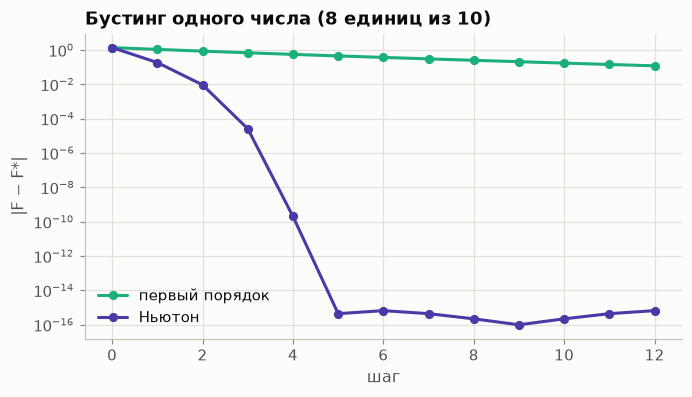

In [23]:
yb = np.array([1] * 8 + [0] * 2, float)
F_opt = math.log(4)
traj = {"первый порядок": [0.0], "Ньютон": [0.0]}
for _ in range(12):
    for name in traj:
        Fk = traj[name][-1]
        p = sig(Fk)
        step = (yb - p).mean() if name == "первый порядок" else (yb - p).sum() / (len(yb) * p * (1 - p))
        traj[name].append(Fk + step)
fig, ax = plt.subplots(figsize=(7, 3.6))
for (name, tr), col in zip(traj.items(), [AQUA, VIOLET]):
    err = np.maximum(np.abs(np.array(tr) - F_opt), 1e-16)
    ax.semilogy(err, "o-", color=col, label=name)
    print(f"{name:15} ошибки: {' '.join(f'{e:.1e}' for e in err[:6])}")
ax.set(xlabel="шаг", ylabel="|F − F*|", title="Бустинг одного числа (8 единиц из 10)")
ax.legend()
plt.show()

## Упражнения

Условия — в `exercises/tasks.md`, решения — в `exercises/solutions.py`. Несколько для разминки прямо здесь:

1. Найдите и классифицируйте экстремумы $2x^3 - 3x^2 - 12x$; где перегиб?
2. Сделайте два шага Ньютона для $x^2 = 10$ из $x_0 = 3$.
3. Для листа с классами $1, 1, 1, 0$ и логитом 0 найдите $w^*$ при $\lambda = 0$ и $\lambda = 1$ и сравните с $\ln 3$.

In [24]:
classify([2, -3, -12, 0])
xx = 3.0
for _ in range(2):
    xx = (xx + 10 / xx) / 2
print("√10 за два шага:", xx, " точно", math.sqrt(10))
y4 = np.array([1.0, 1, 1, 0])
print("лист 1,1,1,0:", [round(float(leaf(y4, np.zeros(4), lam)[0]), 4) for lam in (0, 1)], " ln 3 =", round(math.log(3), 4))

   x = -1.0000: f = +7.0000, f″ = -18.0000 → максимум
   x = +2.0000: f = -20.0000, f″ = +18.0000 → минимум
√10 за два шага: 3.162280701754386  точно 3.1622776601683795
лист 1,1,1,0: [1.0, 0.5]  ln 3 = 1.0986
